<a href="https://colab.research.google.com/github/milleau98/2026-gig-data-analysis/blob/main/notebooks/data-analyses/timeseries_plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pandas numpy matplotlib scipy seaborn

In [2]:
import os
from getpass import getpass

TOKEN = getpass('Enter GitHub token: ')
REPO = "milleau98/2026-gig-data-analysis"

if not os.path.exists("2026-gig-data-analysis"):
    !git clone https://{TOKEN}@github.com/{REPO}.git
else:
    %cd 2026-gig-data-analysis
    !git pull

Enter GitHub token: ··········
Cloning into '2026-gig-data-analysis'...
remote: Enumerating objects: 604, done.
remote: Counting objects: 100% (161/161), done.
remote: Compressing objects: 100% (124/124), done.
remote: Total 604 (delta 100), reused 46 (delta 37), pack-reused 443 (from 1)
Receiving objects: 100% (604/604), 35.32 MiB | 16.27 MiB/s, done.
Resolving deltas: 100% (293/293), done.


In [4]:
import pandas as pd

# stock price

gig_stock_df_monthly = pd.read_csv('2026-gig-data-analysis/data/yfinance/gig_yfinance_monthly.csv', parse_dates=['Date'])

sp500_stock_df_monthly = pd.read_csv('2026-gig-data-analysis/data/yfinance/sp500_yfinance_monthly.csv', parse_dates=['Date'])

# Combine gig and sp500 stock data

stock_df_monthly = pd.concat([gig_stock_df_monthly, sp500_stock_df_monthly])


# google trend data

google_df_monthly = pd.read_csv('2026-gig-data-analysis/data/google_trends/google_trends_monthly.csv', parse_dates=['date'])

# FRED data

fred_df_monthly = pd.read_csv('2026-gig-data-analysis/data/fred/fred_monthly_data.csv', parse_dates=['date'])


stock_df_monthly.head()
fred_df_monthly.head()

,date,month,quarter,year,interest_rate_mtg_data_weekly,cpi_data_monthly,cpi_fesl_data_monthly,rec_sahm_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,consumer_sentiment_composite_amplitude_data_monthly,job_openings_data_monthly,job_hires_data_monthly,job_separations_data_monthly,average_weekly_earnings_data_monthly,gdp_data_quarterly,gdp_real_data_quarterly,cpi_inflation_data_annual,median_income_real_data_annual,median_income_data_annual
0,1854-12-01,12,4,1854,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1855-01-01,1,1,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1855-02-01,2,1,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1855-03-01,3,1,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1855-04-01,4,2,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
google_df_monthly_long = google_df_monthly.melt(
    id_vars=['year', 'month'],
    value_vars= ['Uber','Lyft','DoorDash','Instacart','Fiverr','Upwork', 'Nu skin', 'USANA', 'side hustle','gig','Herbalife','Primerica','Etsy', 'Shopify', 'Udemy'],
    var_name = 'company',
    value_name = 'SearchInterest'
)


In [6]:
# rename columns to match across datasets
gig_stock_df_monthly = gig_stock_df_monthly.rename(columns={'Year': 'year'})
sp500_stock_df_monthly = sp500_stock_df_monthly.rename(columns={'Year': 'year'})

stock_df_monthly = stock_df_monthly.rename(columns={'Year':'year', 'Month':'month', 'Company':'company'})

gig_stock_df_monthly = gig_stock_df_monthly.rename(columns={'Month': 'month'})
sp500_stock_df_monthly = sp500_stock_df_monthly.rename(columns={'Month': 'month'})

# only keep necessary columns before merging
monthly_stock_cols = ['year', 'month', 'company','Close']
monthly_fred_cols = ['year', 'month', 'cpi_inflation_data_annual','unemployment_data_monthly', 'cpi_data_monthly', 'rec_smooth_prob_data_monthly', 'rec_nber_data_monthly',
                     'labor_force_participation_data_monthly', 'job_hires_data_monthly', 'gdp_real_data_quarterly', 'm2_real_data_monthly', 'interest_rate_fedfunds_data_monthly',
                     'consumer_sentiment_data_monthly']

stock_df_monthly = stock_df_monthly[monthly_stock_cols]

fred_df_monthly = fred_df_monthly[monthly_fred_cols]

# Create target variable = close/cpi_data_monthly

google_df_monthly_long = google_df_monthly_long[['year', 'month', 'company','SearchInterest']]

merged_df_monthly = (
    stock_df_monthly
    .merge(google_df_monthly_long, on=['year','company','month'], how='left')
    .merge(fred_df_monthly, on=['year','month'], how='left'))

# Create target variable = close/cpi_data_monthly

merged_df_monthly['target'] = merged_df_monthly['Close'] / merged_df_monthly['cpi_data_monthly']

merged_df_monthly.head(75)

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,labor_force_participation_data_monthly,job_hires_data_monthly,gdp_real_data_quarterly,m2_real_data_monthly,interest_rate_fedfunds_data_monthly,consumer_sentiment_data_monthly,target
0,2018,10,Upwork,19.200001,2.0,2.442583,3.8,252.772,0.46,0.0,62.9,5562.0,20304.874,5640.1,2.19,98.6,0.075958
1,2018,11,Upwork,18.629999,1.0,2.442583,3.8,252.594,0.40,0.0,62.9,5461.0,20304.874,5654.4,2.20,97.5,0.073755
2,2018,12,Upwork,18.110001,1.0,2.442583,3.9,252.767,0.68,0.0,63.0,5400.0,20304.874,5691.7,2.27,98.3,0.071647
3,2019,1,Upwork,19.309999,2.0,1.812210,4.0,252.561,1.76,0.0,63.1,5411.0,20431.641,5725.2,2.40,91.2,0.076457
4,2019,2,Upwork,23.690001,2.0,1.812210,3.8,253.319,1.82,0.0,63.1,5345.0,20431.641,5726.5,2.40,93.8,0.093518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2024,8,Upwork,9.640000,3.0,2.949525,4.2,314.062,0.60,0.0,62.7,4846.0,23478.570,6745.7,5.33,67.9,0.030695
71,2024,9,Upwork,10.450000,2.0,2.949525,4.1,314.732,0.68,0.0,62.7,5071.0,23478.570,6757.7,5.13,70.1,0.033203
72,2024,10,Upwork,13.560000,2.0,2.949525,4.1,315.631,0.50,0.0,62.5,4866.0,23586.542,6758.2,4.83,70.5,0.042962
73,2024,11,Upwork,16.969999,2.0,2.949525,4.2,316.528,0.34,0.0,62.4,4820.0,23586.542,6777.2,4.64,71.8,0.053613


In [8]:
# Create transformed variables so that we don't create spurious correlations

df = merged_df_monthly.sort_values(['company','year','month'])

# Stock returns
df['Return'] = df.groupby('company')['Close'].pct_change()
df['Target_change'] = df.groupby('company')['target'].pct_change()

# Search interest change
df['Search_change'] = df.groupby('company')['SearchInterest'].diff()

# Macro changes
df['Inflation_change'] = df['cpi_data_monthly'].pct_change()
df['Unemployment_change'] = df['unemployment_data_monthly'].diff()
df['InterestRate_change'] = df['interest_rate_fedfunds_data_monthly'].diff()
df['ConsumerSentiment_change'] = df['consumer_sentiment_data_monthly'].diff()

df.head()


/tmp/ipykernel_2062/375824016.py:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Target_change'] = df.groupby('company')['target'].pct_change()
/tmp/ipykernel_2062/375824016.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Inflation_change'] = df['cpi_data_monthly'].pct_change()


,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,interest_rate_fedfunds_data_monthly,consumer_sentiment_data_monthly,target,Return,Target_change,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change
1670,2005,1,3M,38.180622,NaN,3.392747,5.3,191.6,0.06,0.0,...,2.28,95.5,0.199273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1671,2005,2,3M,38.181286,NaN,3.392747,5.4,192.4,0.12,0.0,...,2.50,94.1,0.198447,0.000017,-0.004141,NaN,0.004175,0.1,0.22,-1.4
1672,2005,3,3M,38.977291,NaN,3.392747,5.2,193.1,0.42,0.0,...,2.63,92.6,0.201850,0.020848,0.017147,NaN,0.003638,-0.2,0.13,-1.5
1673,2005,4,3M,34.783459,NaN,3.392747,5.2,193.7,0.18,0.0,...,2.79,87.7,0.179574,-0.107597,-0.110361,NaN,0.003107,0.0,0.16,-4.9
1674,2005,5,3M,35.056538,NaN,3.392747,5.1,193.6,0.22,0.0,...,3.00,86.9,0.181077,0.007851,0.008371,NaN,-0.000516,-0.1,0.21,-0.8


In [9]:
# Create CompanyType Column to split gig/MLM and SP500 Companies
gig_companies = ['Uber','Lyft','DoorDash','Instacart','Grubhub','Fiverr','Upwork',
                 'Etsy','Shopify','Udemy',
                 ]

mlm_companies = ['Herbalife','Primerica','Tupperware','Avon','Nu skin', 'USANA']

def company_type(company):
    if company in gig_companies:
        return 'Gig'
    elif company in mlm_companies:
        return 'MLM'
    else:
        return 'SP500'

df['CompanyType'] = df['company'].apply(company_type)


df.head()

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,consumer_sentiment_data_monthly,target,Return,Target_change,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change,CompanyType
1670,2005,1,3M,38.180622,NaN,3.392747,5.3,191.6,0.06,0.0,...,95.5,0.199273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SP500
1671,2005,2,3M,38.181286,NaN,3.392747,5.4,192.4,0.12,0.0,...,94.1,0.198447,0.000017,-0.004141,NaN,0.004175,0.1,0.22,-1.4,SP500
1672,2005,3,3M,38.977291,NaN,3.392747,5.2,193.1,0.42,0.0,...,92.6,0.201850,0.020848,0.017147,NaN,0.003638,-0.2,0.13,-1.5,SP500
1673,2005,4,3M,34.783459,NaN,3.392747,5.2,193.7,0.18,0.0,...,87.7,0.179574,-0.107597,-0.110361,NaN,0.003107,0.0,0.16,-4.9,SP500
1674,2005,5,3M,35.056538,NaN,3.392747,5.1,193.6,0.22,0.0,...,86.9,0.181077,0.007851,0.008371,NaN,-0.000516,-0.1,0.21,-0.8,SP500


In [31]:
time_series_df = df.groupby(['year', 'month']).agg({
    'Close':'mean',
    'SearchInterest': 'mean',
    'unemployment_data_monthly' : 'mean',
    'cpi_data_monthly': 'mean',
}).reset_index()

time_series_df.head()

,year,month,Close,SearchInterest,unemployment_data_monthly,cpi_data_monthly
0,2005,1,24.018750,NaN,5.3,191.6
1,2005,2,24.417407,NaN,5.4,192.4
2,2005,3,23.618066,NaN,5.2,193.1
3,2005,4,22.840152,NaN,5.2,193.7
4,2005,5,23.876322,NaN,5.1,193.6


In [23]:
gig_ts = df[df['CompanyType'] == 'Gig'].groupby(['year','month']).agg({
    'Close':'mean',
    'SearchInterest':'mean'
}).reset_index()

mlm_ts = df[df['CompanyType'] == 'MLM'].groupby(['year','month']).agg({
    'Close':'mean',
    'SearchInterest':'mean'
}).reset_index()

sp_ts = df[df['CompanyType'] == 'SP500'].groupby(['year','month']).agg({
    'Close':'mean'
}).reset_index()

gig_ts.head()

,year,month,Close,SearchInterest
0,2015,4,22.2400,52.222222
1,2015,5,9.7400,27.560000
2,2015,6,8.7225,26.480769
3,2015,7,12.2895,27.870968
4,2015,8,8.5420,28.982456


In [24]:
macro_ts = df.groupby(['year','month']).agg({
    'unemployment_data_monthly':'mean',
    'cpi_data_monthly':'mean'
}).reset_index()

macro_ts.head()

,year,month,unemployment_data_monthly,cpi_data_monthly
0,2005,1,5.3,191.6
1,2005,2,5.4,192.4
2,2005,3,5.2,193.1
3,2005,4,5.2,193.7
4,2005,5,5.1,193.6


In [26]:
sp_ts = sp_ts.add_suffix('_SP')
sp_ts = sp_ts.rename(columns={'year_SP': 'year', 'month_SP': 'month'})

ts = gig_ts.merge(mlm_ts, on=['year','month'], suffixes=('_Gig','_MLM'))
ts = ts.merge(sp_ts, on=['year', 'month'], suffixes=('', '_SP'))
ts = ts.merge(macro_ts, on=['year','month'])

ts

,year,month,Close_Gig,SearchInterest_Gig,Close_MLM,SearchInterest_MLM,Close_SP,unemployment_data_monthly,cpi_data_monthly
0,2015,4,22.240000,52.222222,39.252427,3.000000,61.413541,5.4,236.222
1,2015,5,9.740000,27.560000,42.864633,3.000000,62.573706,5.6,237.001
2,2015,6,8.722500,26.480769,45.226959,2.666667,61.606742,5.3,237.657
3,2015,7,12.289500,27.870968,42.325033,3.000000,63.179758,5.2,238.034
4,2015,8,8.542000,28.982456,46.394674,2.666667,60.172170,5.1,238.033
...,...,...,...,...,...,...,...,...,...
124,2025,8,73.243000,29.371429,102.908904,1.666667,225.567596,4.3,323.291
125,2025,9,79.168999,27.650000,103.735385,1.333333,227.986886,4.4,324.245
126,2025,10,78.482499,28.438710,95.599235,0.666667,224.209117,NaN,NaN
127,2025,11,69.510000,30.375000,96.239303,1.333333,227.692907,4.5,325.063


In [27]:
ts['time'] = ts['year'].astype(str) + ' M' + ts['month'].astype(str)
ts

,year,month,Close_Gig,SearchInterest_Gig,Close_MLM,SearchInterest_MLM,Close_SP,unemployment_data_monthly,cpi_data_monthly,time
0,2015,4,22.240000,52.222222,39.252427,3.000000,61.413541,5.4,236.222,2015 M4
1,2015,5,9.740000,27.560000,42.864633,3.000000,62.573706,5.6,237.001,2015 M5
2,2015,6,8.722500,26.480769,45.226959,2.666667,61.606742,5.3,237.657,2015 M6
3,2015,7,12.289500,27.870968,42.325033,3.000000,63.179758,5.2,238.034,2015 M7
4,2015,8,8.542000,28.982456,46.394674,2.666667,60.172170,5.1,238.033,2015 M8
...,...,...,...,...,...,...,...,...,...,...
124,2025,8,73.243000,29.371429,102.908904,1.666667,225.567596,4.3,323.291,2025 M8
125,2025,9,79.168999,27.650000,103.735385,1.333333,227.986886,4.4,324.245,2025 M9
126,2025,10,78.482499,28.438710,95.599235,0.666667,224.209117,NaN,NaN,2025 M10
127,2025,11,69.510000,30.375000,96.239303,1.333333,227.692907,4.5,325.063,2025 M11


In [32]:
# Normalize variables

ts['Gig_norm'] = ts['Close_Gig'] / ts['Close_Gig'].dropna().iloc[0]
ts['MLM_norm'] = ts['Close_MLM'] / ts['Close_MLM'].dropna().iloc[0]
ts['SP_norm'] = ts['Close_SP'] / ts['Close_SP'].dropna().iloc[0]
ts['Gig_Search_norm'] = ts['SearchInterest_Gig'] / ts['SearchInterest_Gig'].iloc[0]
ts['MLM_Search_norm'] = ts['SearchInterest_MLM'] / ts['SearchInterest_MLM'].iloc[0]
ts['Unemployment_norm'] = ts['unemployment_data_monthly'] / ts['unemployment_data_monthly'].iloc[0]

ts

,year,month,Close_Gig,SearchInterest_Gig,Close_MLM,SearchInterest_MLM,Close_SP,unemployment_data_monthly,cpi_data_monthly,time,Gig_norm,MLM_norm,SP_norm,Gig_Search_norm,MLM_Search_norm,Unemployment_norm,date
0,2015,4,22.240000,52.222222,39.252427,3.000000,61.413541,5.4,236.222,2015 M4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2015-04-01
1,2015,5,9.740000,27.560000,42.864633,3.000000,62.573706,5.6,237.001,2015 M5,0.437950,1.092025,1.018891,0.527745,1.000000,1.037037,2015-05-01
2,2015,6,8.722500,26.480769,45.226959,2.666667,61.606742,5.3,237.657,2015 M6,0.392199,1.152208,1.003146,0.507079,0.888889,0.981481,2015-06-01
3,2015,7,12.289500,27.870968,42.325033,3.000000,63.179758,5.2,238.034,2015 M7,0.552585,1.078278,1.028759,0.533699,1.000000,0.962963,2015-07-01
4,2015,8,8.542000,28.982456,46.394674,2.666667,60.172170,5.1,238.033,2015 M8,0.384083,1.181957,0.979787,0.554983,0.888889,0.944444,2015-08-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,2025,8,73.243000,29.371429,102.908904,1.666667,225.567596,4.3,323.291,2025 M8,3.293300,2.621721,3.672929,0.562432,0.555556,0.796296,2025-08-01
125,2025,9,79.168999,27.650000,103.735385,1.333333,227.986886,4.4,324.245,2025 M9,3.559757,2.642776,3.712323,0.529468,0.444444,0.814815,2025-09-01
126,2025,10,78.482499,28.438710,95.599235,0.666667,224.209117,NaN,NaN,2025 M10,3.528889,2.435499,3.650809,0.544571,0.222222,NaN,2025-10-01
127,2025,11,69.510000,30.375000,96.239303,1.333333,227.692907,4.5,325.063,2025 M11,3.125450,2.451805,3.707536,0.581649,0.444444,0.833333,2025-11-01


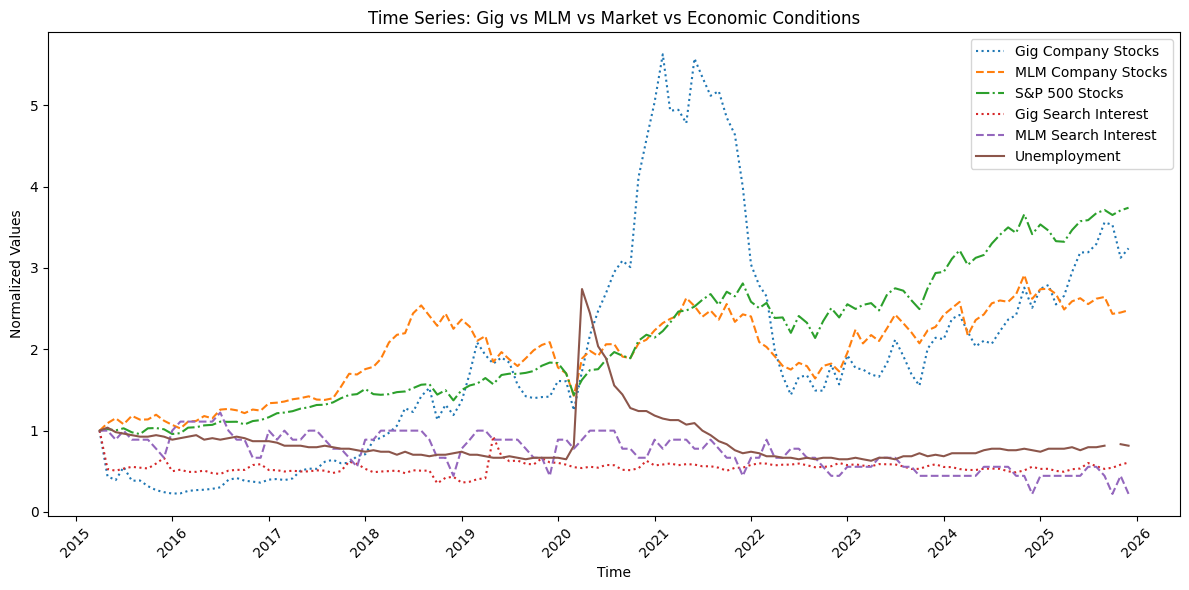

In [41]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Make sure you have a datetime column
ts['date'] = pd.to_datetime(ts[['year', 'month']].assign(day=1))  # first day of each month

plt.figure(figsize=(12,6))

plt.plot(ts['date'], ts['Gig_norm'], label='Gig Company Stocks', linestyle=':')
plt.plot(ts['date'], ts['MLM_norm'], label='MLM Company Stocks', linestyle='--')
plt.plot(ts['date'], ts['SP_norm'], label='S&P 500 Stocks', linestyle='-.')
plt.plot(ts['date'], ts['Gig_Search_norm'], label='Gig Search Interest', linestyle=':')
plt.plot(ts['date'], ts['MLM_Search_norm'], label='MLM Search Interest', linestyle='--')
plt.plot(ts['date'], ts['Unemployment_norm'], label='Unemployment', linestyle='-')

# Format x-axis to show only every year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())  # major ticks every year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # show only year

plt.legend()
plt.title('Time Series: Gig vs MLM vs Market vs Economic Conditions')
plt.xlabel('Time')
plt.ylabel('Normalized Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

